# 🚗 EV Charging Network Performance & Revenue Optimization

## 🏢 Business Problem
The EV charging company wants to identify revenue drivers, understand charging behavior, detect peak demand hours, optimize pricing strategy, and improve infrastructure planning.

## 🎯 Objective
To analyze EV charging session data and generate actionable business insights using Python (Pandas, Matplotlib, Seaborn).

## 📚 Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 📂 Data Loading

In [2]:
df = pd.read_csv("EV_Charging_Analytics_Dataset.csv")

## 🔎 Initial Data Exploration (EDA)

In [3]:
df.head()

,Station_ID,City,State,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Minutes,Session_Date,Revenue,User_Type,Payment_Mode
0,STN_380,Kolkata,West Bengal,Level 2,27.98,49.96,2025-05-19 00:04:06.060650,279.80,Member,UPI
1,STN_369,Mumbai,Maharashtra,Slow,17.31,29.06,2025-04-30 10:02:06.060650,138.48,Member,Wallet
2,STN_278,Bangalore,Karnataka,Fast,33.13,41.30,2025-03-17 23:39:06.060650,397.56,Member,Wallet
3,STN_463,Kolkata,West Bengal,Fast,33.13,62.71,2025-11-09 14:59:06.060650,397.56,Member,UPI
4,STN_684,Delhi,Delhi,Level 2,34.48,41.94,2025-12-07 12:33:06.060650,344.80,Member,Credit Card


In [4]:
df.tail()

,Station_ID,City,State,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Minutes,Session_Date,Revenue,User_Type,Payment_Mode
24995,STN_597,Delhi,Delhi,DC Fast,38.51,65.47,2025-05-13 02:40:06.060650,577.65,Guest,UPI
24996,STN_309,Mumbai,Maharashtra,Level 2,28.35,49.81,2025-12-02 13:11:06.060650,283.50,Guest,Wallet
24997,STN_385,Ahmedabad,Gujarat,DC Fast,55.73,90.33,2025-07-28 23:45:06.060650,835.95,Guest,UPI
24998,STN_715,Delhi,Delhi,Slow,14.40,20.17,2025-08-07 14:34:06.060650,115.20,Guest,UPI
24999,STN_421,Bangalore,Karnataka,Fast,35.78,63.60,2025-11-03 14:41:06.060650,429.36,Guest,UPI


In [6]:
df.shape

(25000, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Station_ID                 25000 non-null  str    
 1   City                       25000 non-null  str    
 2   State                      25000 non-null  str    
 3   Charger_Type               25000 non-null  str    
 4   Energy_Consumed_kWh        25000 non-null  float64
 5   Charging_Duration_Minutes  25000 non-null  float64
 6   Session_Date               25000 non-null  str    
 7   Revenue                    25000 non-null  float64
 8   User_Type                  25000 non-null  str    
 9   Payment_Mode               25000 non-null  str    
dtypes: float64(3), str(7)
memory usage: 1.9 MB


In [8]:
df.describe()

,Energy_Consumed_kWh,Charging_Duration_Minutes,Revenue
count,25000.000000,25000.000000,25000.000000
mean,30.736607,49.141402,371.787417
std,12.647298,21.626383,222.427932
min,5.000000,6.280000,40.000000
25%,20.760000,32.480000,184.880000
50%,28.860000,45.540000,313.960000
75%,39.470000,62.770000,520.455000
max,89.790000,161.240000,1346.850000


## 🧹 Data Cleaning

In [9]:
df.isnull().sum()
df = df.drop_duplicates()

## 🛠 Feature Engineering & Date Conversion

In [11]:
# Convert to datetime
df["Session_Date"] = pd.to_datetime(df["Session_Date"])

# time features
df["Year"] = df["Session_Date"].dt.year
df["Month"] = df["Session_Date"].dt.month
df["Hour"] = df["Session_Date"].dt.hour
df["Day_of_Week"] = df["Session_Date"].dt.day_name()

df["Revenue_per_kWh"] = df["Revenue"] / df["Energy_Consumed_kWh"]

df.head()

,Station_ID,City,State,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Minutes,Session_Date,Revenue,User_Type,Payment_Mode,Year,Month,Hour,Day_of_Week,Revenue_per_kWh
0,STN_380,Kolkata,West Bengal,Level 2,27.98,49.96,2025-05-19 00:04:06.060650,279.80,Member,UPI,2025,5,0,Monday,10.0
1,STN_369,Mumbai,Maharashtra,Slow,17.31,29.06,2025-04-30 10:02:06.060650,138.48,Member,Wallet,2025,4,10,Wednesday,8.0
2,STN_278,Bangalore,Karnataka,Fast,33.13,41.30,2025-03-17 23:39:06.060650,397.56,Member,Wallet,2025,3,23,Monday,12.0
3,STN_463,Kolkata,West Bengal,Fast,33.13,62.71,2025-11-09 14:59:06.060650,397.56,Member,UPI,2025,11,14,Sunday,12.0
4,STN_684,Delhi,Delhi,Level 2,34.48,41.94,2025-12-07 12:33:06.060650,344.80,Member,Credit Card,2025,12,12,Sunday,10.0


## 📊 Key Performance Indicators (KPIs)

In [36]:
total_revenue = df["Revenue"].sum()
total_energy = df["Energy_Consumed_kWh"].sum()
total_sessions = df.shape[0]
avg_charging_duration = df["Charging_Duration_Minutes"].mean()
avg_revenue_per_session = df["Revenue"].mean()
avg_energy_per_session = df["Energy_Consumed_kWh"].mean()
revenue_per_kwh = df["Revenue"].sum() / df["Energy_Consumed_kWh"].sum()

print("========== EV Charging Network KPIs ==========")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Energy Delivered (kWh): {total_energy:,.2f}")
print(f"Total Charging Sessions: {total_sessions:,}")
print(f"Average Charging Duration (Minutes): {avg_charging_duration:.2f}")
print(f"Avg Revenue per Session: {avg_revenue_per_session:,.2f}")
print(f"Avg Energy per Session: {avg_energy_per_session:,.2f}")
print(f"Overall Revenue per kWh: {revenue_per_kwh:,.2f}")
print("==============================================")

========== EV Charging Network KPIs ==========
Total Revenue: 9,294,685.43
Total Energy Delivered (kWh): 768,415.17
Total Charging Sessions: 25,000
Average Charging Duration (Minutes): 49.14
Avg Revenue per Session: 371.79
Avg Energy per Session: 30.74
Overall Revenue per kWh: 12.10


## 💰 Revenue Analysis

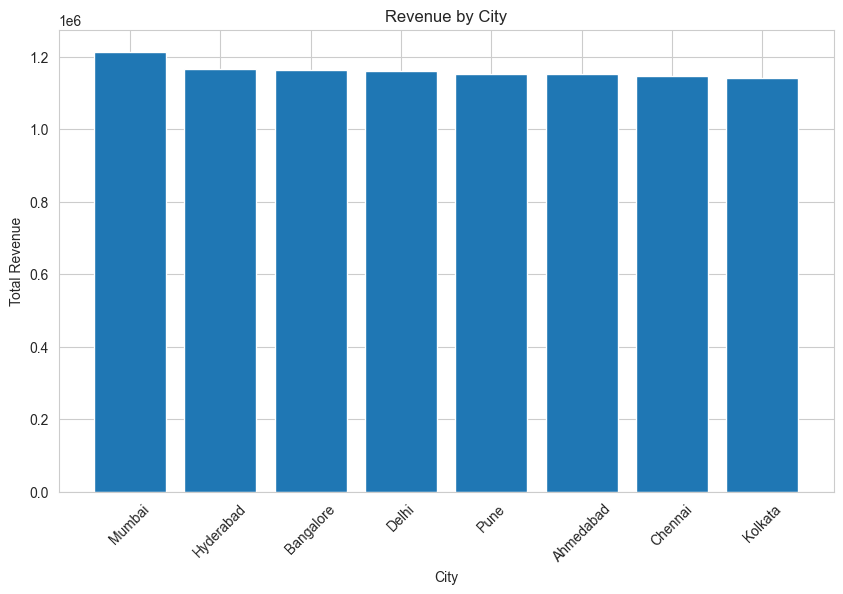

In [37]:
rev_city = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)
plt.bar(rev_city.index, rev_city.values)
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.show()

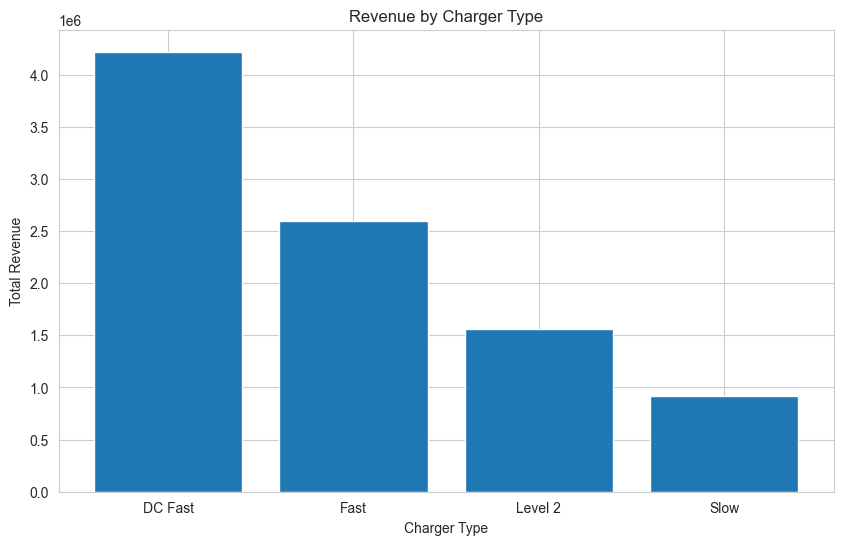

In [38]:
rev_charger = df.groupby("Charger_Type")["Revenue"].sum().sort_values(ascending=False)
plt.bar(rev_charger.index, rev_charger.values)
plt.title("Revenue by Charger Type")
plt.xlabel("Charger Type")
plt.ylabel("Total Revenue")
plt.show()

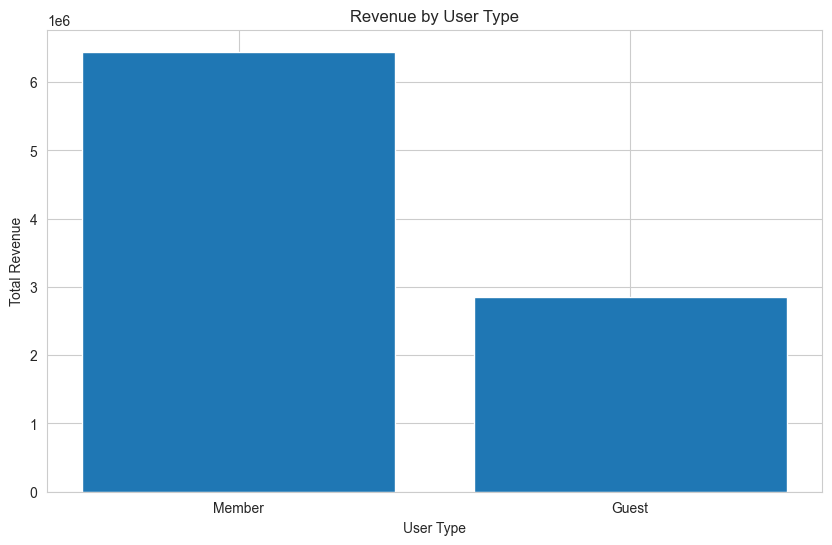

In [39]:
rev_user = df.groupby("User_Type")["Revenue"].sum().sort_values(ascending=False)
plt.bar(rev_user.index, rev_user.values)
plt.title("Revenue by User Type")
plt.xlabel("User Type")
plt.ylabel("Total Revenue")
plt.show()

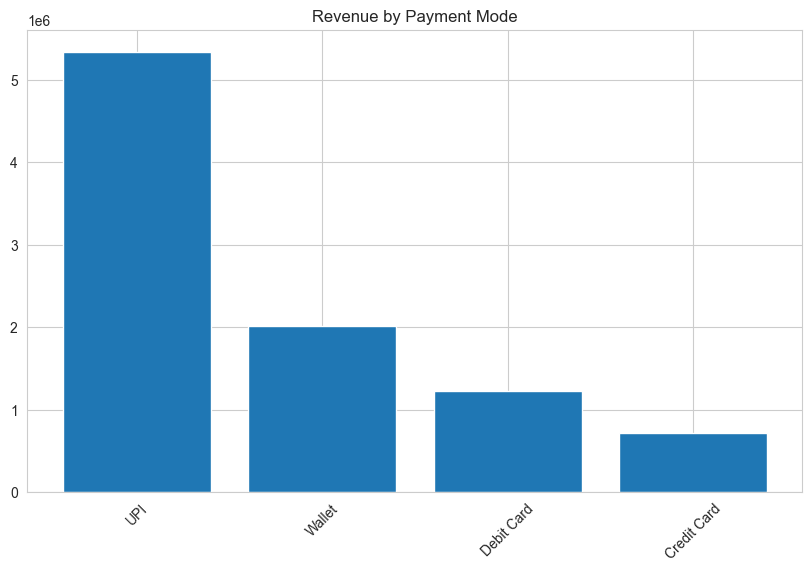

In [40]:
rev_payment = df.groupby("Payment_Mode")["Revenue"].sum().sort_values(ascending=False)
plt.bar(rev_payment.index, rev_payment.values)
plt.title("Revenue by Payment Mode")
plt.xticks(rotation=45)
plt.show()

## 🔌 Charging Session Analysis

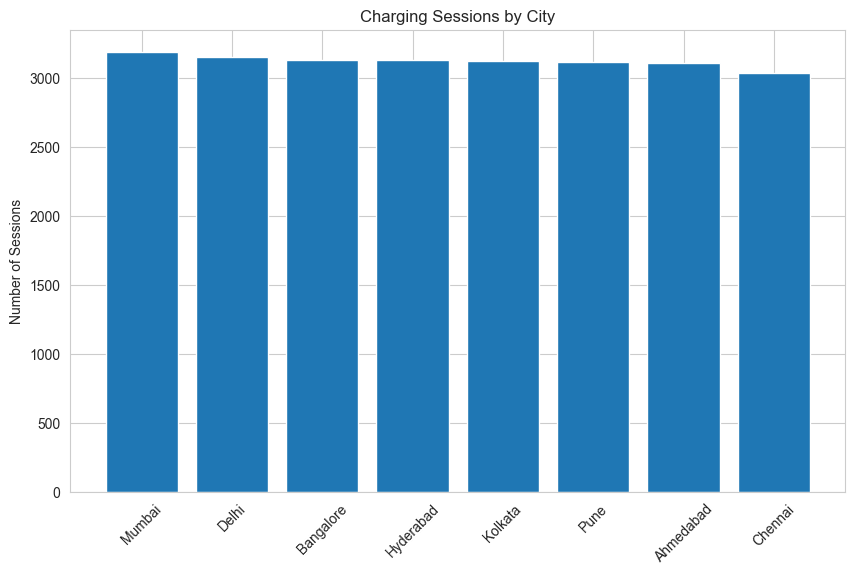

In [41]:
sess_city = df.groupby("City").size().sort_values(ascending=False)
plt.bar(sess_city.index, sess_city.values)
plt.title("Charging Sessions by City")
plt.xticks(rotation=45)
plt.ylabel("Number of Sessions")
plt.show()

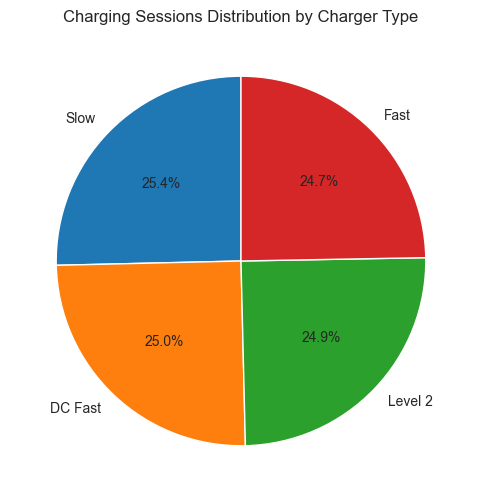

In [6]:
sess_charger = df.groupby("Charger_Type").size().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(sess_charger.values, labels=sess_charger.index, autopct="%1.1f%%", startangle=90)
plt.title("Charging Sessions Distribution by Charger Type")
plt.show()

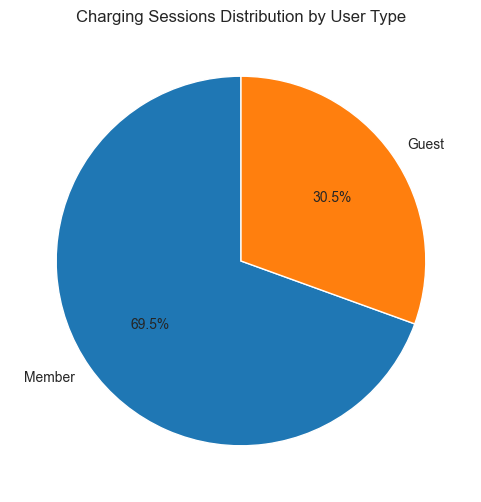

In [5]:
sess_user = df.groupby("User_Type").size().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(sess_user.values, labels=sess_user.index, autopct="%1.1f%%", startangle=90)
plt.title("Charging Sessions Distribution by User Type")
plt.show()

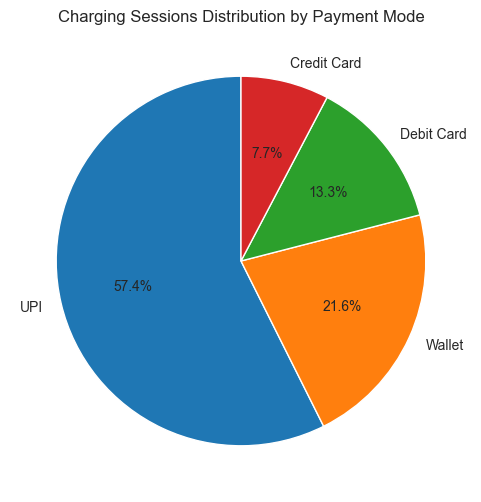

In [44]:
sess_payment = df.groupby("Payment_Mode").size().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(sess_payment.values, labels=sess_payment.index, autopct="%1.1f%%", startangle=90)
plt.title("Charging Sessions Distribution by Payment Mode")
plt.show()

## 📈 Monthly Revenue Trend

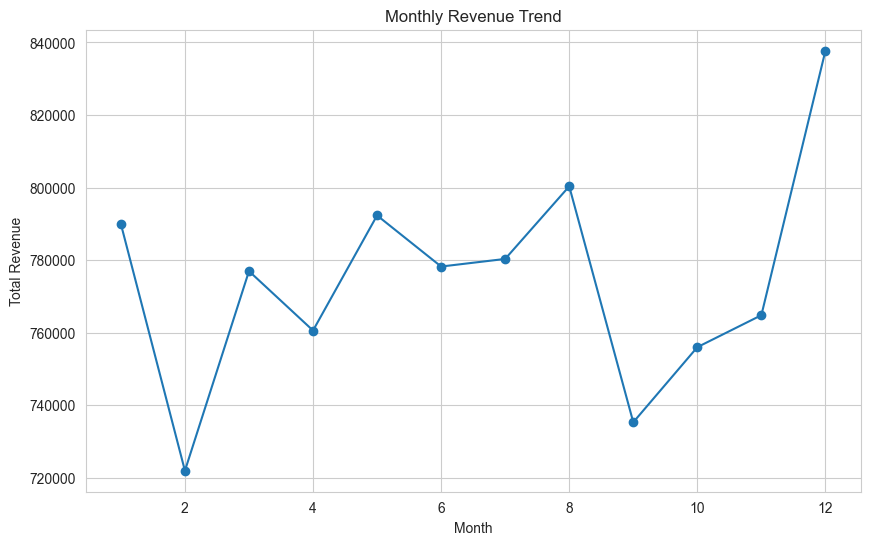

In [21]:
monthly_rev = df.groupby("Month")["Revenue"].sum()
plt.plot(monthly_rev.index, monthly_rev.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

## 🕒 Peak Charging Hours

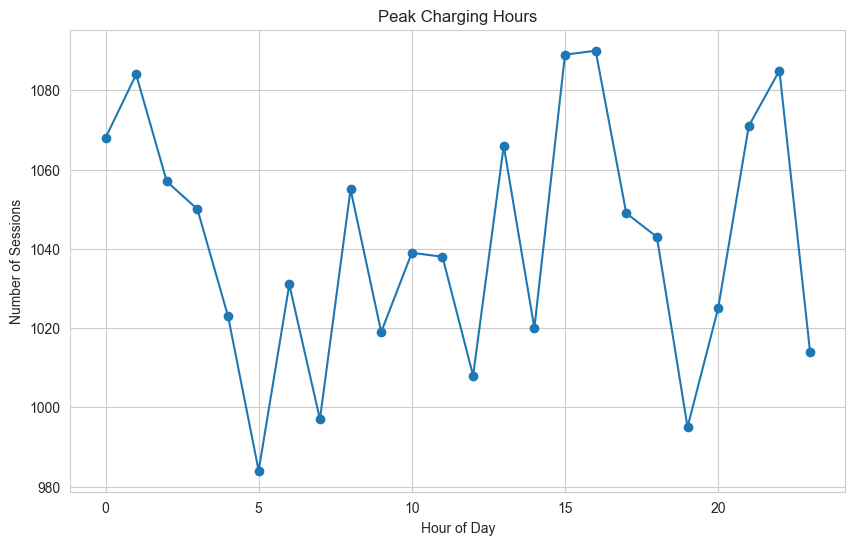

In [22]:
peak_hour = df.groupby("Hour").size()
plt.plot(peak_hour.index, peak_hour.values, marker="o")
plt.title("Peak Charging Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.show()

## ⚡ Energy vs Revenue

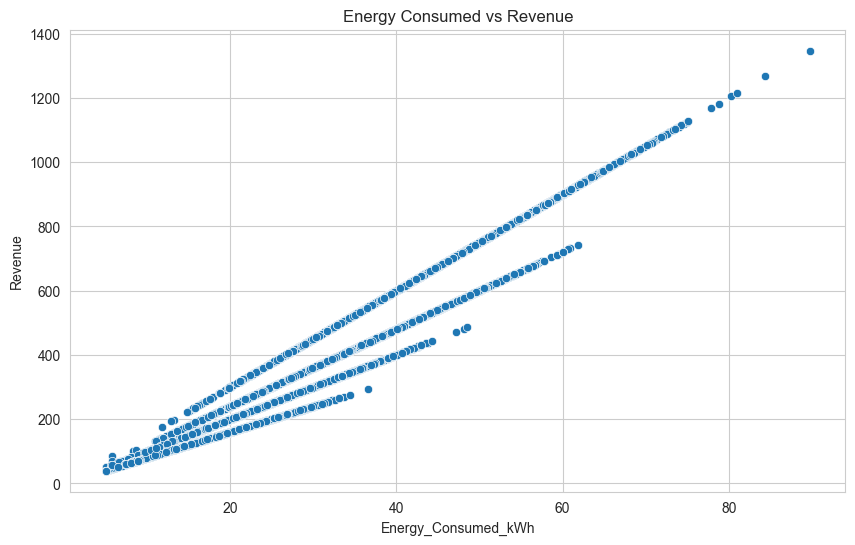

In [23]:
sns.scatterplot(data=df, x="Energy_Consumed_kWh", y="Revenue")
plt.title("Energy Consumed vs Revenue")
plt.show()

## 📊 Energy Consumption Distribution

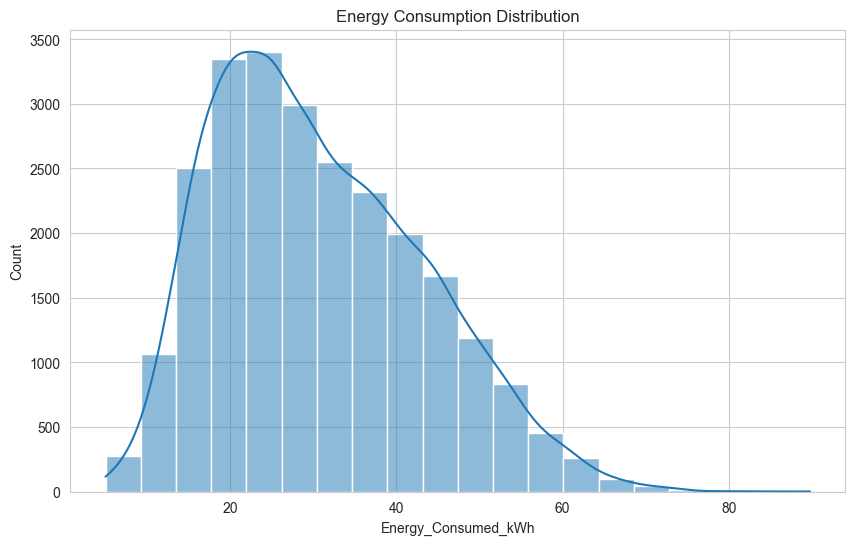

In [24]:
sns.histplot(df["Energy_Consumed_kWh"], bins=20, kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

## 📊 Correlation Heatmap

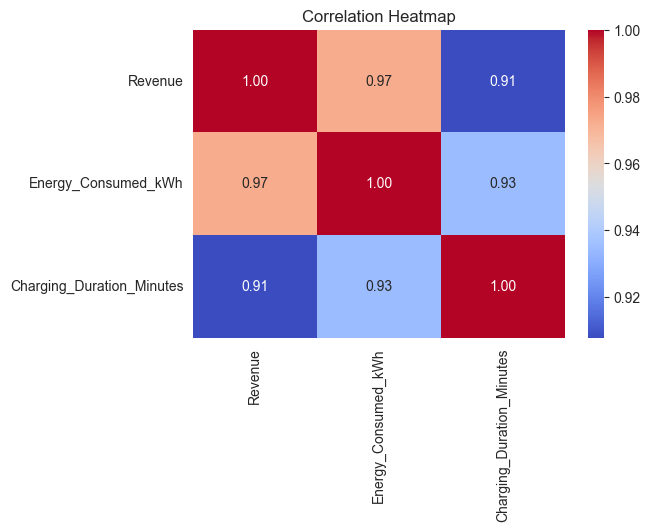

In [27]:
corr = df[["Revenue", "Energy_Consumed_kWh", "Charging_Duration_Minutes"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 💡 Key Insights

### ➣ Mumbai is the highest revenue and highest session city.

### ➣ DC Fast chargers generate the most revenue, while Slow chargers are used more frequently.

### ➣ Members contribute the majority of revenue and sessions. 

### ➣ UPI is the most preferred and highest revenue-generating payment mode.

### ➣ December records the highest monthly revenue.

### ➣ 4 PM is the peak charging hour.

### ➣ Revenue has a very strong correlation with energy consumption (0.97)